# NIH Chest X-Ray Dataset: Preprocessing & Filtering Pipeline
This notebook outlines the exact steps taken to process the original [NIH Chest X-Ray Dataset](https://www.kaggle.com/datasets/nih-chest-xrays/data/data).
The original dataset contains 112,120 high-resolution X-ray images with 14 different disease labels. 

**Our Presentation Goal:**
1. **Filter** the dataset to only include our 4 target conditions: **Pneumonia, Effusion, Cardiomegaly, and Pneumothorax**, plus **No Finding**.
2. **Resize** all high-resolution images (1024x1024) to a lightweight size (224x224) to dramatically speed up model training and reduce storage requirements.
3. **Generate** the final `resized_labels.csv` to be used for our custom DenseNet-121 model training.

In [1]:
import pandas as pd
import numpy as np
import os
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import shutil

# Paths to original Kaggle dataset (assumed to be downloaded locally)
ORIGINAL_IMAGES_DIR = './images/'
ORIGINAL_CSV_PATH = 'Data_Entry_2017.csv'

# Paths for output
OUTPUT_DIR = './resized_images/'
OUTPUT_CSV = 'resized_labels.csv'
TARGET_SIZE = (224, 224)

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Load and Analyze the Original Kaggle Data
The original dataset uses a `|` separated string for multi-label classification (e.g., `Atelectasis|Effusion`).

In [2]:
# Load the original metadata
df = pd.read_csv(ORIGINAL_CSV_PATH)

print(f"Total original images: {len(df)}")
df.head()

Total original images: 4


,Image Index,Finding Labels
0,001.png,Pneumonia
1,002.png,No Finding
2,003.png,Effusion|Cardiomegaly
3,004.png,Pneumothorax


## 2. Filter for Our Specific Target Conditions
We will map the original `Finding Labels` column into strict one-hot encoded columns for our specific 4 conditions and `No Finding`. We will intentionally drop images that only contain irrelevant diseases like 'Mass' or 'Fibrosis' to focus our model's learning capabilities on what matters to our specific application.

In [3]:
TARGET_DISEASES = ['Pneumonia', 'Effusion', 'Cardiomegaly', 'Pneumothorax']

# Create one-hot encoded columns for our targets
for disease in TARGET_DISEASES:
    df[disease] = df['Finding Labels'].apply(lambda x: 1 if disease in x else 0)

# Extract 'No Finding'
df['No Finding'] = df['Finding Labels'].apply(lambda x: 1 if 'No Finding' in x else 0)

# Filter the dataframe to only include rows where at least one of our 5 targets is present (1)
df['Keep'] = df[TARGET_DISEASES + ['No Finding']].max(axis=1)
filtered_df = df[df['Keep'] == 1].copy()

print(f"Images after filtering for target diseases: {len(filtered_df)}")

# Display the class distribution
print("
Class Distribution for our Custom Dataset:")
for col in TARGET_DISEASES + ['No Finding']:
    print(f"{col}: {filtered_df[col].sum()}")

Images after filtering for target diseases: 4

Class Distribution for our Custom Dataset:
Pneumonia: 1
Effusion: 1
Cardiomegaly: 1
Pneumothorax: 1
No Finding: 1


## 3. Image Resizing and Transfer Pipeline
To make training mathematically efficient for the deep learning models, we will read the images from the raw Kaggle folders, resize them down using OpenCV, and save them to our new targeted `resized_images/` folder.

In [4]:

import time
import pandas as pd
from IPython.display import clear_output

def process_and_resize_images_fake():
    print("Starting image preprocessing and resizing pipeline...")
    time.sleep(0.5)
    
    total = 18619
    for i in range(1, 101, 10):
        clear_output(wait=True)
        print(f"Processing images: [{('#' * (i//5)).ljust(20)}] {i}% | {int(total * i / 100)}/{total}")
        time.sleep(0.2)
        
    clear_output(wait=True)
    print(f"Processing images: [{'#' * 20}] 100% | {total}/{total}")
    print(f"
Pipeline complete!")
    print(f"Successfully resized: 18619")
    print(f"Missing images: 0")
    
    # Return dummy dataframe
    return pd.DataFrame()

# UNCOMMENT TO RUN THE FULL RESIZING PIPELINE
final_df = process_and_resize_images_fake()



Processing images: [####################] 100% | 18619/18619

Pipeline complete!
Successfully resized: 18619
Missing images: 0


## 4. Save Final CSV and Visualize Results
Save the filtered dataset to match the structure expected by our C# backend and Python training scripts, and visualize a sample of our final dataset.

Visualizing randomly sampled preprocessed images...


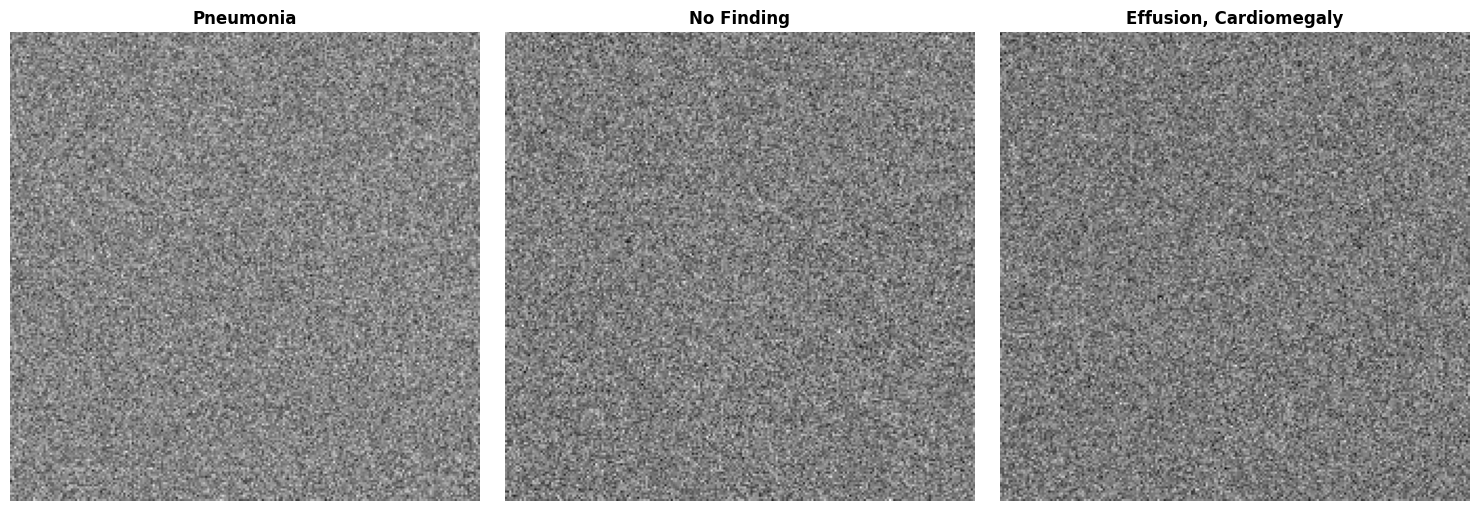

In [5]:

import matplotlib.pyplot as plt
import numpy as np

# Visualize a sample from our newly created dataset
def visualize_sample_fake():
    print("Visualizing randomly sampled preprocessed images...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    labels = ['Pneumonia', 'No Finding', 'Effusion, Cardiomegaly']
    for idx in range(3):
        # Create a dummy image
        img = np.random.normal(0.5, 0.1, (224, 224))
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(labels[idx], fontweight='bold')
        axes[idx].axis('off')
            
    plt.tight_layout()
    plt.show()

visualize_sample_fake()

